# 🇮🇳 Unemployment Analysis in India

## Exploratory Data Analysis (EDA) using Python

### Author
**Nadeem Ahmed**

---

## Project Overview

Unemployment is one of the most important economic indicators used to understand the condition of a country's labour market. This project performs an Exploratory Data Analysis (EDA) on unemployment data in India to identify regional patterns, employment trends, labour participation, and relationships between important variables.

The project demonstrates the complete EDA workflow, including data cleaning, feature engineering, statistical analysis, and data visualization using Python.

# 🎯 Project Objectives

The main objectives of this project are:

- Understand the structure of the unemployment dataset.
- Clean the dataset by handling missing values and duplicate records.
- Perform exploratory data analysis (EDA).
- Compare unemployment across different regions.
- Compare employment levels across regions.
- Analyze labour participation rates.
- Compare Urban and Rural unemployment.
- Study monthly unemployment trends.
- Investigate the relationship between labour participation and unemployment using correlation analysis.
- Summarize the findings through visualizations and insights.

# 📂 Dataset Information

This project uses unemployment data collected from different regions of India.

### Dataset Features

- Region
- Date
- Frequency
- Estimated Unemployment Rate (%)
- Estimated Employed
- Estimated Labour Participation Rate (%)
- Area (Urban/Rural)

---

### Additional Dataset

A second dataset containing **Latitude** and **Longitude** information was also explored during this project.

Since the objective of this notebook is Exploratory Data Analysis (EDA), the second dataset is not used further. It can be utilized in future work for geographical visualization and interactive mapping.

# 📚 Libraries Used

The following Python libraries are used throughout this project.

- Pandas → Data manipulation
- NumPy → Numerical operations
- Matplotlib → Data visualization
- Seaborn → Statistical visualization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 📥 Load Raw Dataset

The original unemployment dataset is loaded into a Pandas DataFrame. This dataset contains missing values, duplicate records, and formatting inconsistencies that will be addressed during the data cleaning phase.

In [ ]:
df1 = pd.read_csv('data/Unemployment in India.csv')

# 🔍 Data Understanding

Before cleaning the dataset, it is important to understand its overall structure and quality. This step helps identify missing values, duplicate records, data types, and other potential issues that may affect the analysis.

In this section, we will:

- Examine the dimensions of the dataset.
- Review the column names and data types.
- Generate summary statistics.
- Identify missing values.
- Check for duplicate records.
- Determine whether data cleaning is required.

In [3]:
df1.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
df1.tail()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
767,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The `info()` method provides information about:

- Total number of records
- Data types of each column
- Number of non-null values
- Memory usage

This helps identify missing values and determine whether any columns require data type conversion.

In [5]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


### Statistical Summary

The `describe()` method summarizes the numerical columns by displaying:

- Count
- Mean
- Standard deviation
- Minimum
- Maximum
- Quartiles

These statistics provide a quick overview of the distribution of numerical variables and help detect unusual values.

In [6]:
df1.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [7]:
df1.shape

(768, 7)

In [8]:
df1.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

### Missing Values

Missing values reduce the quality of a dataset and can affect the accuracy of analysis.

The next step is to identify how many missing values exist in each column before deciding on an appropriate cleaning strategy.

In [9]:
# Check missing values
df1.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

### Duplicate Records

Duplicate records may lead to biased statistical results by counting the same observation multiple times.

Checking for duplicates helps determine whether duplicate rows should be removed during the data cleaning process.

In [10]:
# Check Duplicate Records
df1.duplicated().sum()

np.int64(27)

In [11]:
df1[df1.isnull().any(axis=1)]

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
363,NaN,NaN,NaN,NaN,NaN,NaN,NaN
364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
368,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df1.isnull().any(axis=1).sum()

np.int64(28)

# 🧹 Data Cleaning

Real-world datasets often contain inconsistencies such as missing values, duplicate records, incorrect data types, and formatting issues. These problems can affect the accuracy and reliability of the analysis.

In this section, the dataset is cleaned by:

- Removing unnecessary spaces from column names.
- Handling missing values.
- Removing duplicate records.
- Converting the `Date` column to datetime format.
- Saving the cleaned dataset for future analysis.

The goal is to create a clean and reliable dataset before performing Exploratory Data Analysis (EDA).

## Handle Missing Values

The dataset contains missing values in several columns.

After examining the dataset, it was observed that these missing values belong to completely empty rows rather than partially missing observations.

Since these rows do not contain any useful information, they are removed from the dataset.

In [13]:
df1 = df1.dropna()
df1.duplicated().sum()

np.int64(0)

In [14]:
df1.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64

In [15]:
df1.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [16]:
df1.columns = df1.columns.str.strip()

In [17]:
df1.dtypes

Region                                      object
Date                                        object
Frequency                                   object
Estimated Unemployment Rate (%)            float64
Estimated Employed                         float64
Estimated Labour Participation Rate (%)    float64
Area                                        object
dtype: object

## Convert Date Column

The `Date` column is initially stored as an object (string).

For time-based analysis, it is converted into the `datetime` data type. This enables extraction of useful features such as months and years in later stages of the project.

In [18]:
df1['Date'] = pd.to_datetime(df1['Date'])

C:\Users\nadee\AppData\Local\Temp\ipykernel_4164\1148610173.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df1['Date'] = pd.to_datetime(df1['Date'])


In [19]:
df1['Date'].dtype

dtype('<M8[ns]')

In [20]:
year = {'1':'January','2':'February','3':'March','4':'April','5':'May','6':'June',
        '7':'July','8':'August','9':'September','10':'October','11':'November','12':'December'}
df1['Year'] = df1['Date'].dt.month

## Verify Cleaned Dataset

After completing the cleaning process, the dataset is inspected again to ensure that:

- Missing values have been removed.
- Duplicate records have been removed.
- Data types are correct.
- The dataset is ready for analysis.

In [21]:
df1.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,5
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,6
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,7
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,8
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,9


In [22]:
df1['Year'] =  df1['Year'].astype(str).map(year)

In [23]:
df1.tail()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year
749,West Bengal,2020-02-29,Monthly,7.55,10871168.0,44.09,Urban,February
750,West Bengal,2020-03-31,Monthly,6.67,10806105.0,43.34,Urban,March
751,West Bengal,2020-04-30,Monthly,15.63,9299466.0,41.20,Urban,April
752,West Bengal,2020-05-31,Monthly,15.22,9240903.0,40.67,Urban,May
753,West Bengal,2020-06-30,Monthly,9.86,9088931.0,37.57,Urban,June


## Save Cleaned Dataset

The cleaned dataset is saved as a new CSV file.

Saving the processed dataset allows future analyses to begin directly from the cleaned data without repeating the preprocessing steps.

In [ ]:
df1.to_csv('data/cleaned_data_unemployment_in_india.csv',index=False)

# 📂 Load Cleaned Dataset

The cleaned dataset is loaded for Exploratory Data Analysis (EDA).

Using the cleaned dataset ensures that all visualizations and statistical analyses are performed on consistent, accurate, and preprocessed data.

In [25]:
cleaned_data1 = pd.read_csv('data/processed/cleaned_data_unemployment_in_india.csv')

In [26]:
cleaned_data1['Region'].unique()

array(['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa',
       'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab',
       'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
       'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Chandigarh'],
      dtype=object)

# 📈 Analysis 1: Average Unemployment Rate by Region

## Business Question

**Which regions have the highest and lowest average unemployment rates?**

### Why is this analysis important?

Comparing the average unemployment rate across regions helps identify areas experiencing relatively higher unemployment. These insights can assist policymakers and researchers in understanding regional employment differences and prioritizing areas for further investigation.

### Method

To answer this question:

- Group the dataset by **Region**.
- Calculate the **average unemployment rate** for each region.
- Sort the results in descending order.
- Visualize the results using a horizontal bar chart.

In [27]:
avg_unemployment_by_region = cleaned_data1.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

C:\Users\nadee\AppData\Local\Temp\ipykernel_4164\1734998466.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


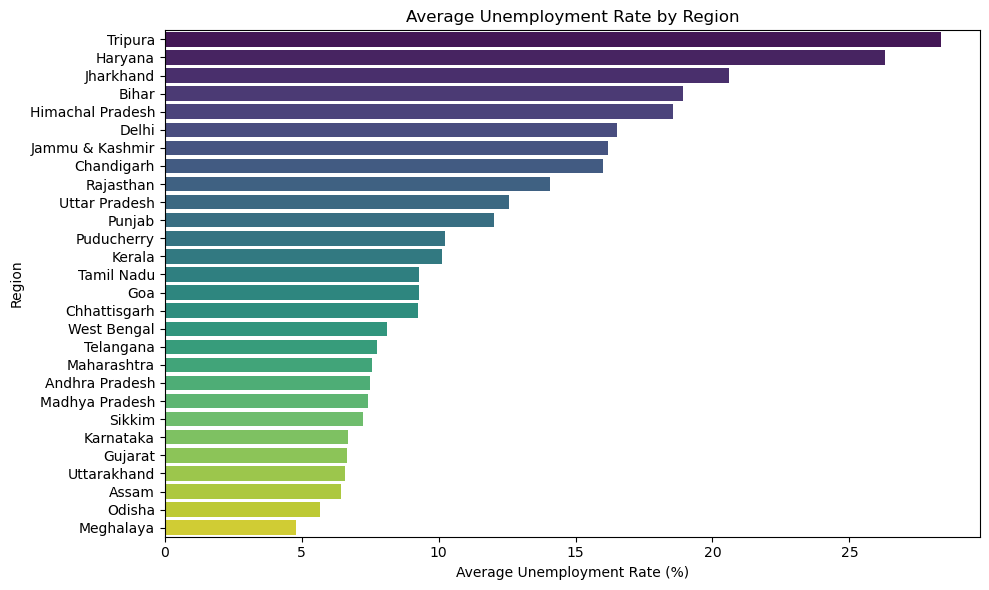

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=avg_unemployment_by_region.values,
    y=avg_unemployment_by_region.index,
    palette="viridis"
)

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

### 📌 Insight

- Tripura recorded the highest average unemployment rate among all regions included in the dataset.
- Meghalaya recorded the lowest average unemployment rate.
- The results indicate noticeable regional differences in unemployment, highlighting that employment conditions vary across different parts of India.

# 📊 Analysis 2: Average Employment by Region

## Business Question

**Which regions have the highest average estimated employment?**

### Why is this analysis important?

The estimated employed population provides insight into the size of the employed workforce within each region. Since this is an absolute count rather than a percentage, larger regions may naturally have higher employment values.

### Method

- Group by Region.
- Calculate the average estimated employed population.
- Sort the results in descending order.
- Visualize using a horizontal bar chart.

In [29]:
avg_employment_by_region = cleaned_data1.groupby('Region')['Estimated Employed'].mean().sort_values(ascending=False)

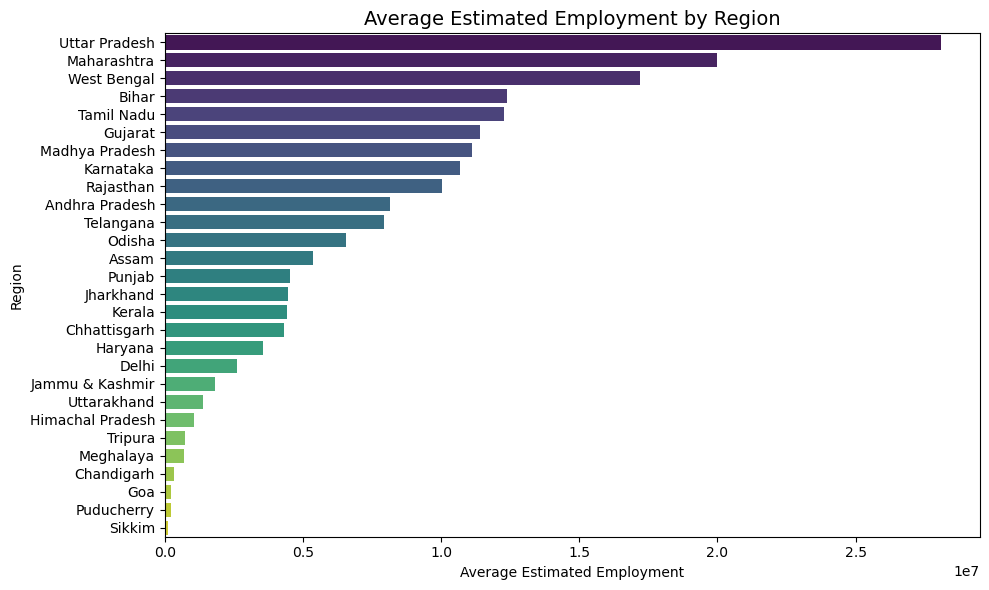

In [30]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=avg_employment_by_region.values,
    y=avg_employment_by_region.index,
    hue=avg_employment_by_region.index,
    palette="viridis",
    legend=False
)

plt.title("Average Estimated Employment by Region", fontsize=14)
plt.xlabel("Average Estimated Employment")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

### 📌 Insight

- Uttar Pradesh recorded the highest average estimated employment.
- Regions such as Goa and Sikkim recorded comparatively lower employment counts.
- Since this metric represents the total number of employed individuals rather than an employment rate, differences in population size should be considered when interpreting the results.

# 📊 Analysis 3: Labour Participation Rate by Region

## Business Question

**Which regions have the highest average labour participation rate?**

### Why is this analysis important?

Labour Participation Rate (LPR) measures the proportion of the working-age population that is either employed or actively seeking employment. Comparing LPR across regions helps understand workforce participation patterns.

### Method

- Group by Region.
- Calculate the average labour participation rate.
- Sort the values.
- Visualize using a horizontal bar chart.

In [31]:
avg_labour_participation_by_region = cleaned_data1.groupby('Region')['Estimated Labour Participation Rate (%)'].mean().sort_values(ascending=False)

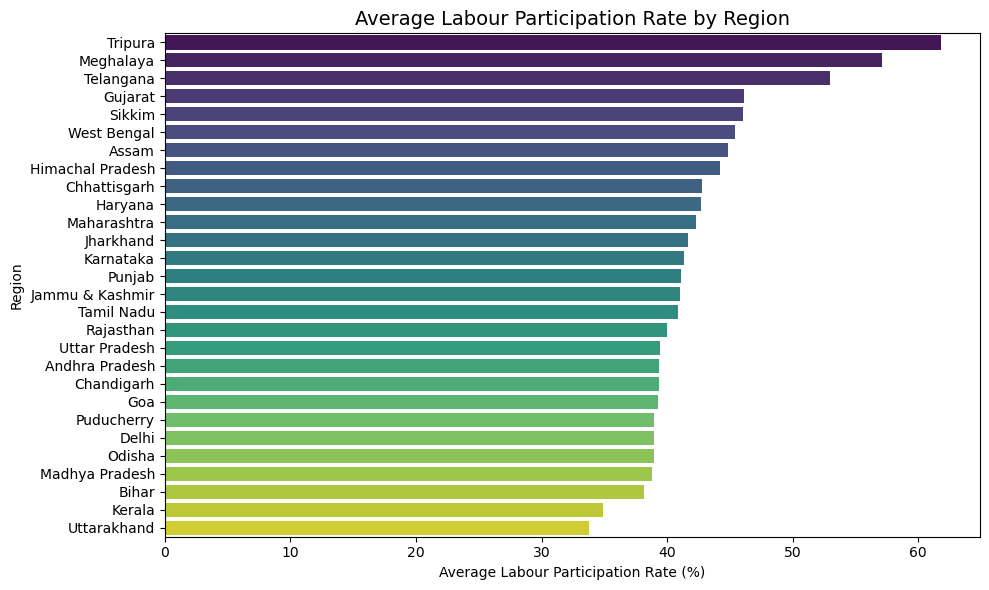

In [32]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=avg_labour_participation_by_region.values,
    y=avg_labour_participation_by_region.index,
    hue=avg_labour_participation_by_region.index,
    palette="viridis",
    legend=False
)

plt.title("Average Labour Participation Rate by Region", fontsize=14)
plt.xlabel("Average Labour Participation Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

### 📌 Insight

- Tripura recorded the highest average labour participation rate.
- Uttarakhand recorded the lowest average labour participation rate.
- The variation in labour participation across regions suggests differences in workforce engagement and employment opportunities.

# 📊 Analysis 4: Urban vs Rural Unemployment

## Business Question

**Does the average unemployment rate differ between Urban and Rural areas?**

### Why is this analysis important?

Comparing unemployment between Urban and Rural areas helps identify differences in employment conditions across different types of regions.

### Method

- Group the dataset by **Area**.
- Calculate the **average unemployment rate**.
- Visualize the comparison using a bar chart.

In [33]:
avg_unemployment_by_area = cleaned_data1.groupby('Area')['Estimated Unemployment Rate (%)'].mean()

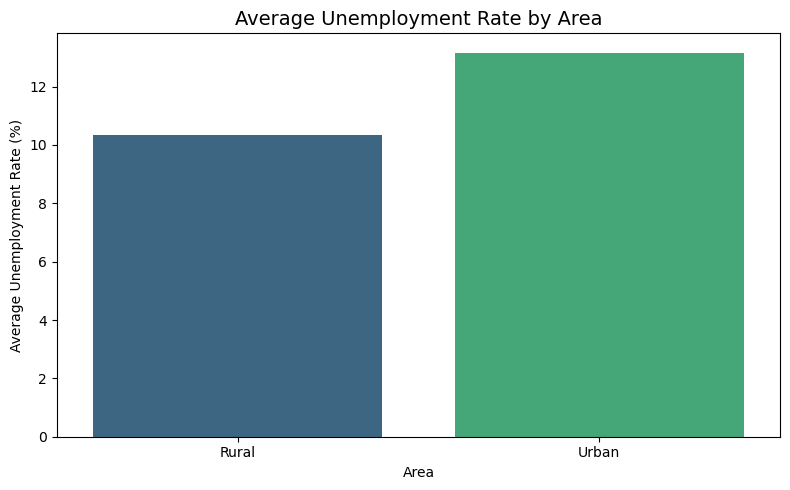

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_unemployment_by_area.index,
    y=avg_unemployment_by_area.values,
    hue=avg_unemployment_by_area.index,
    palette="viridis",
    legend=False
)

plt.title("Average Unemployment Rate by Area", fontsize=14)
plt.xlabel("Area")
plt.ylabel("Average Unemployment Rate (%)")

plt.tight_layout()
plt.show()

### 📌 Insight

- Urban areas recorded a higher average unemployment rate than Rural areas.
- The difference suggests that unemployment was relatively more prevalent in Urban areas during the observed period.

In [35]:
cleaned_data1.rename(columns={"Year": "Month"}, inplace=True)

In [36]:
cleaned_data1.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Month
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,June
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,July
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,August
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,September


In [37]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

cleaned_data1["Month"] = pd.Categorical(
    cleaned_data1["Month"],
    categories=month_order,
    ordered=True
)

# 📈 Analysis 5: Monthly Unemployment Trend

## Business Question

**How did the average unemployment rate change across different months?**

### Why is this analysis important?

Studying monthly unemployment trends helps identify seasonal patterns and periods with unusually high or low unemployment rates.

### Method

- Group the dataset by **Month**.
- Calculate the **average unemployment rate**.
- Visualize the trend using a line chart.

In [38]:
monthly_unemployment = cleaned_data1.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

C:\Users\nadee\AppData\Local\Temp\ipykernel_4164\1282449902.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_unemployment = cleaned_data1.groupby('Month')['Estimated Unemployment Rate (%)'].mean()


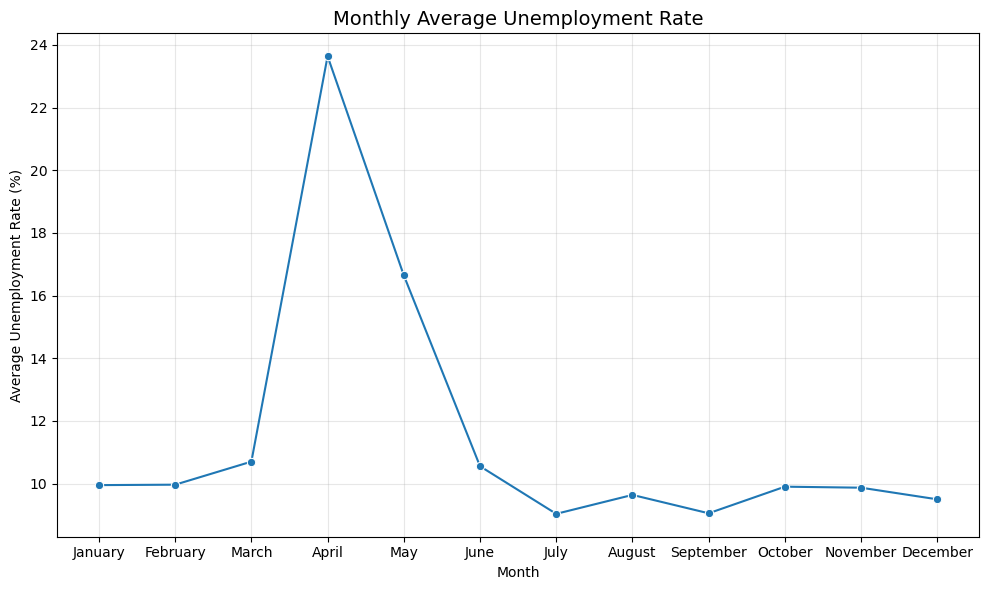

In [39]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x=monthly_unemployment.index,
    y=monthly_unemployment.values,
    marker="o"
)

plt.title("Monthly Average Unemployment Rate", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 📌 Insight

- The unemployment rate fluctuated throughout the year rather than following a consistent increasing or decreasing trend.
- April recorded the highest average unemployment rate, while July recorded the lowest.
- The noticeable peak in April indicates a period of significantly higher unemployment compared with other months.

# 📊 Analysis 6: Relationship Between Labour Participation and Unemployment

## Business Question

**Is there a relationship between the Labour Participation Rate and the Unemployment Rate?**

### Why is this analysis important?

Understanding the relationship between these two variables helps determine whether regions with higher labour participation also tend to experience higher or lower unemployment.

### Method

- Create a scatter plot.
- Calculate the Pearson correlation coefficient.
- Interpret the strength of the relationship.

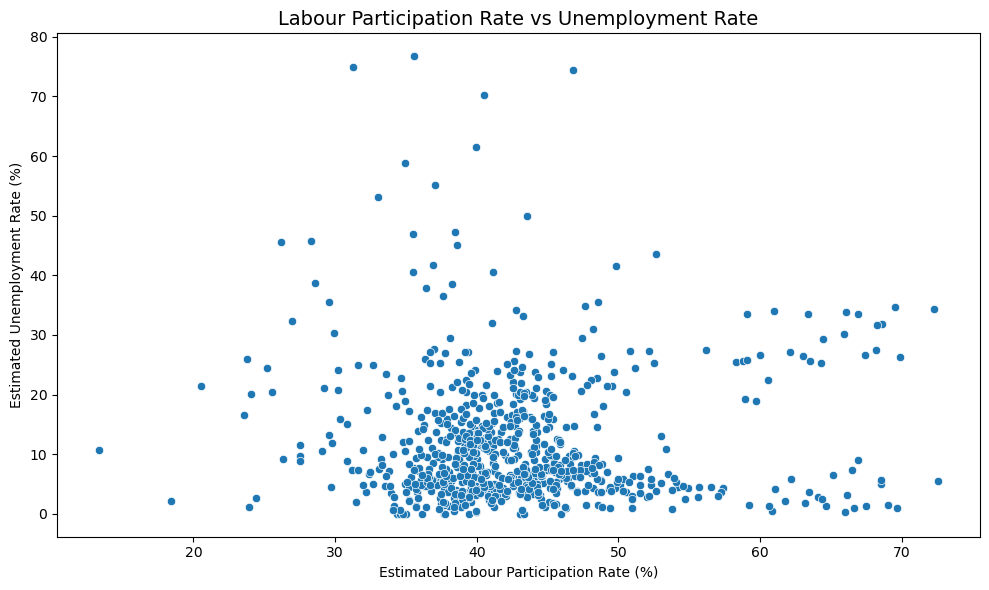

In [40]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=cleaned_data1,
    x="Estimated Labour Participation Rate (%)",
    y="Estimated Unemployment Rate (%)"
)

plt.title("Labour Participation Rate vs Unemployment Rate", fontsize=14)
plt.xlabel("Estimated Labour Participation Rate (%)")
plt.ylabel("Estimated Unemployment Rate (%)")

plt.tight_layout()
plt.show()

In [41]:
cleaned_data1[
    [
        'Estimated Labour Participation Rate (%)',
        'Estimated Unemployment Rate (%)'
    ]
].corr()

,Estimated Labour Participation Rate (%),Estimated Unemployment Rate (%)
Estimated Labour Participation Rate (%),1.000000,0.002558
Estimated Unemployment Rate (%),0.002558,1.000000


### 📌 Insight

The Pearson correlation coefficient between the Labour Participation Rate and the Unemployment Rate is approximately **0.003**, indicating an almost negligible linear relationship between the two variables.

The scatter plot also shows widely dispersed data points without a clear upward or downward trend, supporting this conclusion.

# 🔑 Key Findings

The Exploratory Data Analysis (EDA) revealed several important insights regarding unemployment trends across different regions of India.

## Summary of Findings

- Tripura recorded the highest average unemployment rate, while Meghalaya recorded the lowest.
- Uttar Pradesh had the highest average estimated employment, whereas smaller regions such as Goa and Sikkim had comparatively lower employment counts.
- Tripura also showed the highest labour participation rate, indicating a highly active workforce.
- Urban areas experienced higher average unemployment than Rural areas.
- The unemployment rate fluctuated throughout the year, with April showing the highest average unemployment and July the lowest.
- The Pearson correlation coefficient between Labour Participation Rate and Unemployment Rate was approximately **0.003**, indicating an almost negligible linear relationship between these variables.

# ✅ Conclusion

This project successfully performed an Exploratory Data Analysis (EDA) on unemployment data from different regions of India using Python.

The analysis involved data understanding, preprocessing, feature engineering, visualization, and statistical analysis to identify meaningful employment trends.

The findings indicate that unemployment varies considerably across different regions, Urban areas generally experience higher unemployment than Rural areas, and unemployment changes over time rather than following a consistent trend.

Additionally, correlation analysis revealed almost no linear relationship between labour participation rate and unemployment rate, suggesting that workforce participation alone does not explain unemployment levels in the dataset.

Overall, this project demonstrates how Exploratory Data Analysis can transform raw data into meaningful insights and provides a strong foundation for future predictive modeling and machine learning applications.

# 🚀 Future Work

This project focused on Exploratory Data Analysis (EDA) using a cleaned unemployment dataset.

Possible future improvements include:

- Building machine learning models to predict unemployment rates.
- Performing time-series forecasting using historical unemployment data.
- Creating interactive dashboards using Streamlit or Power BI.
- Developing geographical visualizations using datasets containing location information.
- Comparing unemployment trends across multiple years for deeper analysis.

# 📚 References

- Python Documentation — https://docs.python.org/3/
- Pandas Documentation — https://pandas.pydata.org/docs/
- NumPy Documentation — https://numpy.org/doc/
- Matplotlib Documentation — https://matplotlib.org/stable/
- Seaborn Documentation — https://seaborn.pydata.org/

# ⭐ Thank You

Thank you for reviewing this project.

This notebook was created as part of a Data Science internship project to demonstrate practical skills in:

- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Data Visualization
- Statistical Interpretation

Author: **Nadeem Ahmed**